In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset — using full path
df = pd.read_csv("/Titanic-Dataset.csv")

# Check the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Step 2: Data Cleaning

# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing Age with mean
df["Age"].fillna(df["Age"].mean(), inplace=True)

# Fill missing Embarked with most common value
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop irrelevant columns
df.drop(columns=["Cabin"], inplace=True)

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData cleaning complete! ✅")

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Data cleaning complete! ✅


/tmp/ipykernel_1776/2428451847.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_1776/2428451847.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
# Step 3: Create Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# Create Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Survival rate by Age Group
print("Survival Rate by Age Group:")
print(df.groupby("AgeGroup")["Survived"].mean().round(2))

# Survival rate by Embarkation Port
print("\nSurvival Rate by Embarkation Port:")
print(df.groupby("Embarked")["Survived"].mean().round(2))

# Survival rate by Family Size
print("\nSurvival Rate by Family Size:")
print(df.groupby("FamilySize")["Survived"].mean().round(2))

Survival Rate by Age Group:
AgeGroup
Child         0.58
Teen          0.43
YoungAdult    0.33
Adult         0.42
Senior        0.34
Name: Survived, dtype: float64

Survival Rate by Embarkation Port:
Embarked
C    0.55
Q    0.39
S    0.34
Name: Survived, dtype: float64

Survival Rate by Family Size:
FamilySize
0     0.30
1     0.55
2     0.58
3     0.72
4     0.20
5     0.14
6     0.33
7     0.00
10    0.00
Name: Survived, dtype: float64


/tmp/ipykernel_1776/1511154561.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("AgeGroup")["Survived"].mean().round(2))


/tmp/ipykernel_1776/737477078.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


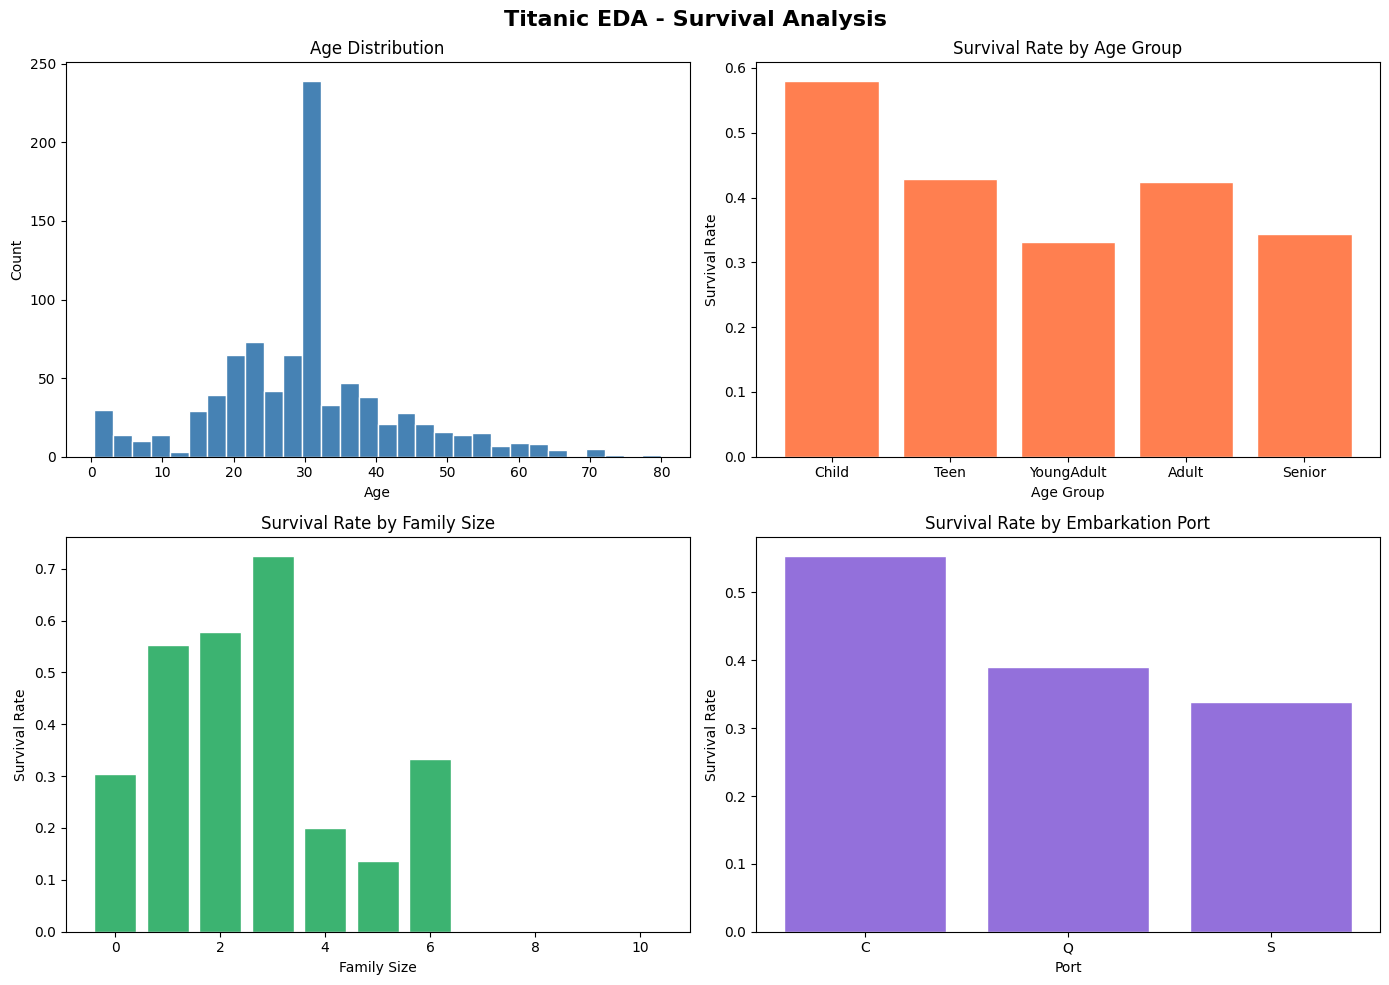

In [ ]:
# Step 4: Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Titanic EDA - Survival Analysis", fontsize=16, fontweight='bold')

# Plot 1: Age Distribution
axes[0,0].hist(df["Age"], bins=30, color="steelblue", edgecolor="white")
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Count")

# Plot 2: Survival by Age Group
age_survival = df.groupby("AgeGroup")["Survived"].mean()
axes[0,1].bar(age_survival.index, age_survival.values, color="coral", edgecolor="white")
axes[0,1].set_title("Survival Rate by Age Group")
axes[0,1].set_xlabel("Age Group")
axes[0,1].set_ylabel("Survival Rate")

# Plot 3: Survival by Family Size
family_survival = df.groupby("FamilySize")["Survived"].mean()
axes[1,0].bar(family_survival.index, family_survival.values, color="mediumseagreen", edgecolor="white")
axes[1,0].set_title("Survival Rate by Family Size")
axes[1,0].set_xlabel("Family Size")
axes[1,0].set_ylabel("Survival Rate")

# Plot 4: Survival by Embarkation Port
port_survival = df.groupby("Embarked")["Survived"].mean()
axes[1,1].bar(port_survival.index, port_survival.values, color="mediumpurple", edgecolor="white")
axes[1,1].set_title("Survival Rate by Embarkation Port")
axes[1,1].set_xlabel("Port")
axes[1,1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

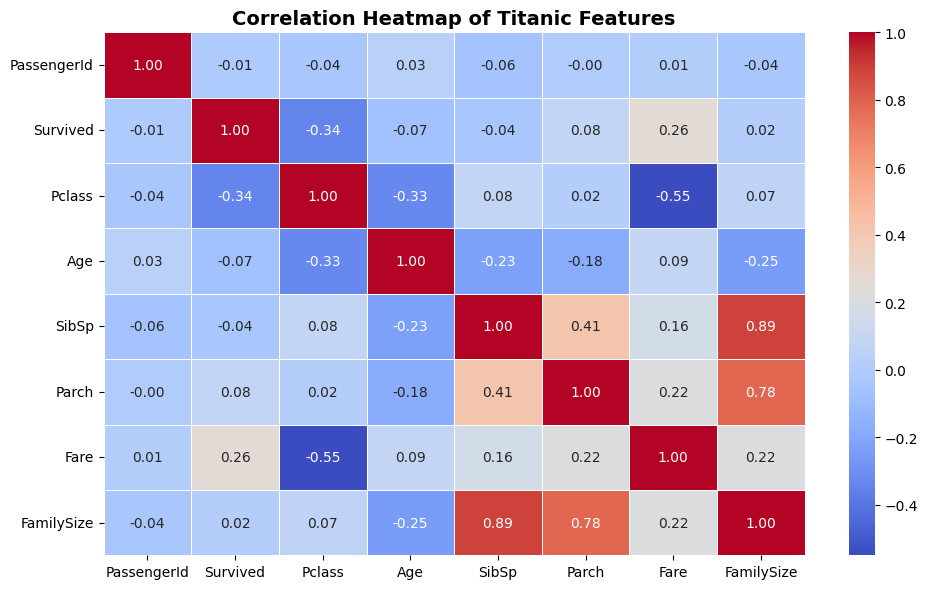


✅ All visualizations complete!


In [ ]:
# Step 5: Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)
plt.title("Correlation Heatmap of Titanic Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ All visualizations complete!")